# 02 — Train baseline XGBoost

Mục tiêu:
1. Train XGBoost trên full PhysioNet (40k patient) với MLflow tracking.
2. Plot ROC + PR curves, confusion matrix, threshold sweep.
3. Tìm threshold tối ưu cho **Utility score** (đây là metric chính của PhysioNet).
4. Register model vào MLflow Registry (nếu Utility > baseline) — backend sẽ load từ Registry.

Logic train vẫn ở `ml/src/train.py`, notebook chỉ orchestrate + visualize.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)

from ml.src.evaluate import compute_metrics, compute_utility
from ml.src.preprocess import (
    TARGET_COL,
    get_feature_columns,
    load_and_split,
)
from ml.src.train import train_model

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
mlflow.set_experiment("sepsis-baseline")
print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

2026/05/11 21:50:57 INFO mlflow.tracking.fluent: Experiment with name 'sepsis-baseline' does not exist. Creating a new experiment.


Project root: D:\S2_Year4\Emerging Technologies\Project
MLflow tracking URI: file:///d:/S2_Year4/Emerging%20Technologies/Project/ml/notebooks/mlruns


## 1. Load + split

Để train full ~40k patient (~5-10 phút trên laptop), set `max_patients=None`. Để smoke test nhanh, set 2000-5000.

In [2]:
# ⚙️ Tune ở đây
MAX_PATIENTS = None  # None = full 40k. Đặt 5000 để debug nhanh.

train_df, val_df = load_and_split(max_patients=MAX_PATIENTS)
print(f"Train: {train_df.shape}, sepsis rate: {train_df[TARGET_COL].mean():.4f}")
print(f"Val:   {val_df.shape}, sepsis rate: {val_df[TARGET_COL].mean():.4f}")

2026-05-11 21:50:57,911 INFO Loading 40336 PSV files from 2 dirs
2026-05-11 21:53:06,249 INFO Loaded shape=(1552210, 42), patients=40336
2026-05-11 21:53:26,205 INFO Split: train=1240596 rows (32268 patients), val=311614 rows (8068 patients)


Train: (1240596, 119), sepsis rate: 0.0180
Val:   (311614, 119), sepsis rate: 0.0178


## 2. Train baseline

In [3]:
booster, metrics = train_model(
    train_df=train_df,
    val_df=val_df,
    num_boost_round=500,
    early_stopping_rounds=30,
    mlflow_run_name="baseline_xgb_full",
    register_model=False,  # Set True khi muốn promote vào Registry
)
print("Val metrics:", metrics)

2026-05-11 21:53:26,361 INFO Training XGBoost on 117 features, 1240596 train rows, 311614 val rows


[0]	train-auc:0.79166	train-aucpr:0.08859	val-auc:0.77180	val-aucpr:0.07739
[50]	train-auc:0.87697	train-aucpr:0.17051	val-auc:0.83144	val-aucpr:0.10508
[100]	train-auc:0.89892	train-aucpr:0.22617	val-auc:0.83653	val-aucpr:0.10943
[146]	train-auc:0.91383	train-aucpr:0.26524	val-auc:0.83829	val-aucpr:0.10959


2026-05-11 21:54:48,443 INFO Top 10 features by gain: [('ICULOS', 7301.04248046875), ('FiO2_missing_flag', 4509.623046875), ('pH_missing_flag', 3415.72216796875), ('Unit2', 3402.321044921875), ('Unit1', 3314.77392578125), ('FiO2_ffill', 3229.1787109375), ('FiO2', 2840.56982421875), ('Lactate_ffill', 2409.752197265625), ('Temp_roll_mean_6h', 2230.74755859375), ('EtCO2', 1941.947021484375)]
d:\S2_Year4\Emerging Technologies\Project\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:54:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/05/11 21:54:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the mod

Val metrics: {'auroc': 0.8375448279313191, 'auprc': 0.11023864643309667, 'utility': 0.7889475227544535, 'threshold': 0.5, 'positive_rate': 0.1889645522986772}


## 3. Score val set + visualize curves

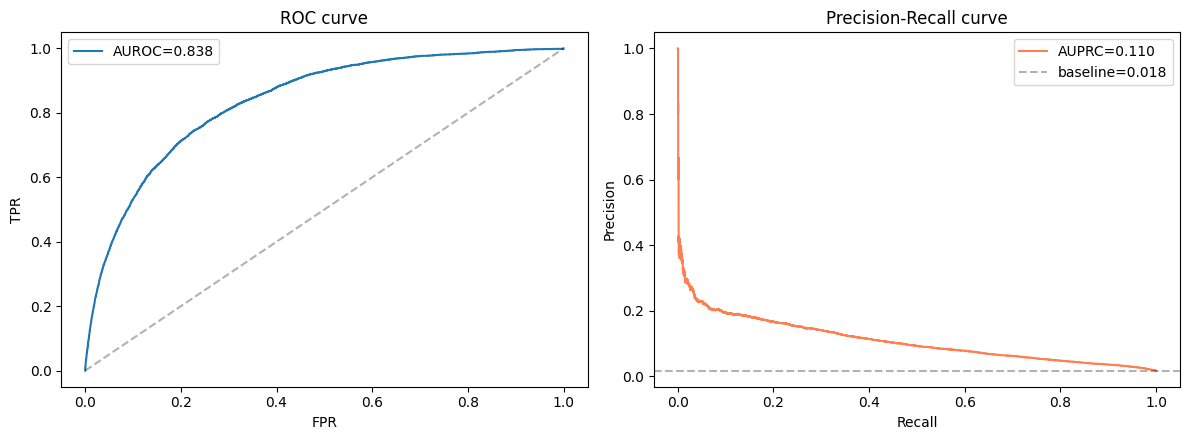

In [4]:
feature_cols = get_feature_columns(train_df)
dval = xgb.DMatrix(val_df[feature_cols].to_numpy(np.float32), feature_names=feature_cols)
y_score = booster.predict(dval, iteration_range=(0, booster.best_iteration + 1))
y_true = val_df[TARGET_COL].to_numpy()

fpr, tpr, _ = roc_curve(y_true, y_score)
prec, rec, pr_thr = precision_recall_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, label=f"AUROC={metrics['auroc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve"); axes[0].legend()

axes[1].plot(rec, prec, label=f"AUPRC={metrics['auprc']:.3f}", color="coral")
axes[1].axhline(y_true.mean(), color="k", linestyle="--", alpha=0.3,
                label=f"baseline={y_true.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve"); axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Threshold sweep cho Utility score

Default threshold=0.5 hiếm khi tối ưu cho imbalanced data. Sweep 0.05→0.95
tìm threshold maximize PhysioNet Utility — đây là threshold sẽ deploy.

Best threshold: 0.70 → Utility=0.8248, alert_rate=0.0719


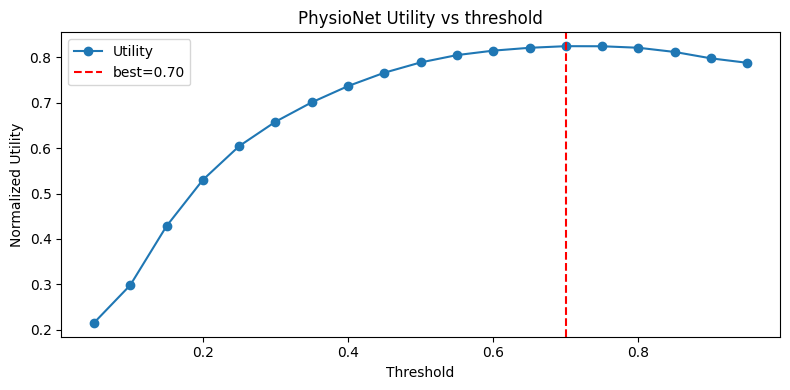

In [5]:
thresholds = np.arange(0.05, 0.96, 0.05)
results = []
df_eval = val_df[["patient_id", "ICULOS", TARGET_COL]].copy()
for thr in thresholds:
    df_eval["prediction"] = (y_score >= thr).astype(int)
    u = compute_utility(df_eval)
    results.append({
        "threshold": thr,
        "utility": u,
        "alert_rate": df_eval["prediction"].mean(),
    })
sweep = pd.DataFrame(results)
best = sweep.loc[sweep["utility"].idxmax()]
print(f"Best threshold: {best['threshold']:.2f} → Utility={best['utility']:.4f}, alert_rate={best['alert_rate']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep["threshold"], sweep["utility"], marker="o", label="Utility")
ax.axvline(best["threshold"], color="red", linestyle="--",
           label=f"best={best['threshold']:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Normalized Utility")
ax.set_title("PhysioNet Utility vs threshold"); ax.legend()
plt.tight_layout()
plt.show()

## 5. Confusion matrix tại best threshold

In [6]:
best_thr = float(best["threshold"])
y_pred = (y_score >= best_thr).astype(int)
cm = confusion_matrix(y_true, y_pred)
print(f"Confusion matrix @ threshold={best_thr:.2f}:")
print(pd.DataFrame(cm, index=["true_neg", "true_pos"], columns=["pred_neg", "pred_pos"]))

tn, fp, fn, tp = cm.ravel()
print(f"\nSensitivity (recall): {tp / (tp + fn):.4f}")
print(f"Specificity:          {tn / (tn + fp):.4f}")
print(f"Precision:            {tp / (tp + fp):.4f}")

Confusion matrix @ threshold=0.70:
          pred_neg  pred_pos
true_neg    286055     20006
true_pos      3150      2403

Sensitivity (recall): 0.4327
Specificity:          0.9346
Precision:            0.1072


## 6. Top features by gain

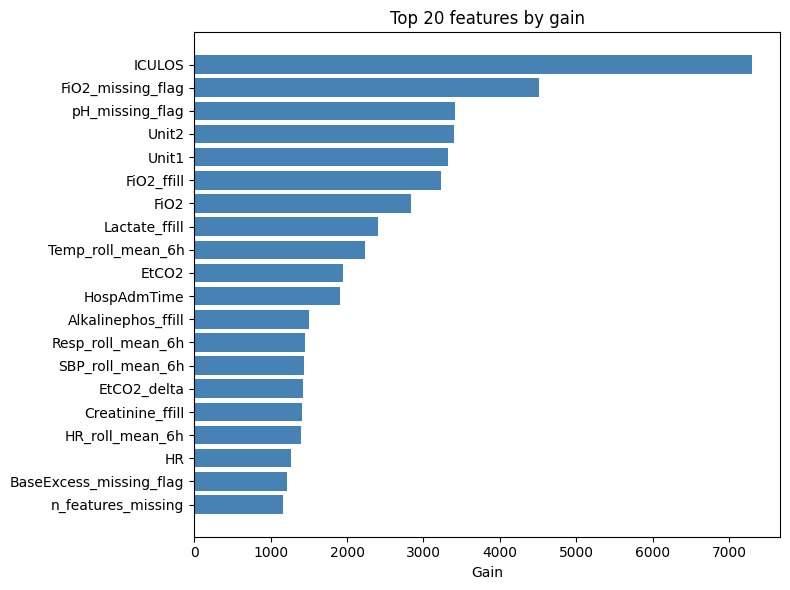

In [7]:
importance = booster.get_score(importance_type="gain")
imp_df = (
    pd.DataFrame(importance.items(), columns=["feature", "gain"])
    .sort_values("gain", ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["feature"][::-1], imp_df["gain"][::-1], color="steelblue")
ax.set_xlabel("Gain"); ax.set_title("Top 20 features by gain")
plt.tight_layout()
plt.show()

## 7. (Optional) Re-train + register vào MLflow Registry

Khi hài lòng với baseline → re-train + `register_model=True` để backend
load từ Registry (stage=Production). Run cell này thủ công sau khi review kết quả.

In [9]:
# Bỏ comment khi muốn register
booster_final, metrics_final = train_model(
    train_df=train_df,
    val_df=val_df,
    num_boost_round=500,
    early_stopping_rounds=30,
    threshold=best_thr,
    mlflow_run_name="baseline_xgb_registered",
    register_model=True,
)
print("Registered. Sang MLflow UI promote stage='Production' để backend pickup.")

2026-05-11 22:01:08,881 INFO Training XGBoost on 117 features, 1240596 train rows, 311614 val rows


[0]	train-auc:0.79166	train-aucpr:0.08859	val-auc:0.77180	val-aucpr:0.07739
[50]	train-auc:0.87697	train-aucpr:0.17051	val-auc:0.83144	val-aucpr:0.10508
[100]	train-auc:0.89892	train-aucpr:0.22617	val-auc:0.83653	val-aucpr:0.10943
[146]	train-auc:0.91383	train-aucpr:0.26524	val-auc:0.83829	val-aucpr:0.10959


2026-05-11 22:02:31,604 INFO Top 10 features by gain: [('ICULOS', 7301.04248046875), ('FiO2_missing_flag', 4509.623046875), ('pH_missing_flag', 3415.72216796875), ('Unit2', 3402.321044921875), ('Unit1', 3314.77392578125), ('FiO2_ffill', 3229.1787109375), ('FiO2', 2840.56982421875), ('Lactate_ffill', 2409.752197265625), ('Temp_roll_mean_6h', 2230.74755859375), ('EtCO2', 1941.947021484375)]
d:\S2_Year4\Emerging Technologies\Project\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:02:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/05/11 22:02:36 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the mod

Registered. Sang MLflow UI promote stage='Production' để backend pickup.
